# 1 · Data Quality, Feature Analysis & Naive Baselines

**Goal:** Assess the quality of raw data in the database, understand feature distributions and correlations (raw features only — no engineered features), perform PCA, and establish naive baselines for demand forecasting.

| Section | Purpose |
|---|---|
| 1. Data Quality | Missing values, gaps, duplicates, outliers |
| 2. Feature Distributions | Histograms & box-plots for each raw feature |
| 3. Correlation Analysis | Pairwise correlation heatmap |
| 4. PCA | Variance explained, component loadings |
| 5. Naive Baselines | Persistence & seasonal-average MAE/RMSE/MAPE |

In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

# Load env from project root
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
load_dotenv(os.path.join(PROJECT_ROOT, '.env'))

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.2f}'.format)

engine = create_engine(
    f"postgresql://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}@"
    f"{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME')}"
)
print('DB connection OK')

DB connection OK


---
## 1 · Data Quality

In [2]:
# ── Load raw tables ──────────────────────────────────────────────────────────
demand = pd.read_sql(text("""
    SELECT date_time AS timestamp,
           "actual_demand(MW)" AS actual_demand
    FROM energy_demand ORDER BY date_time
"""), engine)
demand['timestamp'] = pd.to_datetime(demand['timestamp'], utc=True).dt.tz_localize(None)

weather = pd.read_sql(text("""
    SELECT date_time AS timestamp,
           "temperature_2m(°C)"      AS temperature,
           "relative_humidity_2m(%)" AS humidity,
           "rain(mm)"               AS rain,
           "snow_depth(m)"          AS snow_depth,
           "snowfall(cm)"           AS snowfall
    FROM weather ORDER BY date_time
"""), engine)
weather['timestamp'] = pd.to_datetime(weather['timestamp'], utc=True).dt.tz_localize(None)

holidays = pd.read_sql(text("""
    SELECT date, is_public_holiday, is_national, holiday_type
    FROM holidays ORDER BY date
"""), engine)
holidays['date'] = pd.to_datetime(holidays['date'])

print(f'Demand:   {len(demand):>8,} rows  |  {demand["timestamp"].min().date()} → {demand["timestamp"].max().date()}')
print(f'Weather:  {len(weather):>8,} rows  |  {weather["timestamp"].min().date()} → {weather["timestamp"].max().date()}')
print(f'Holidays: {len(holidays):>8,} rows  |  {holidays["date"].min().date()} → {holidays["date"].max().date()}')

Demand:     62,811 rows  |  2019-01-01 → 2026-03-02
Weather:    62,829 rows  |  2019-01-01 → 2026-03-02
Holidays:    3,287 rows  |  2019-01-01 → 2027-12-31


In [3]:
# ── 1a. Missing values ────────────────────────────────────────────────────────
print('=== Missing Values ===')
for name, df in [('Demand', demand), ('Weather', weather)]:
    missing = df.isnull().sum()
    total = missing.sum()
    if total:
        print(f'\n⚠  {name}: {total} missing values')
        print(missing[missing > 0].to_string())
    else:
        print(f'✓  {name}: no missing values')

=== Missing Values ===
✓  Demand: no missing values
✓  Weather: no missing values


In [4]:
# ── 1b. Duplicate timestamps ──────────────────────────────────────────────────
print('=== Duplicate Timestamps ===')
for name, df in [('Demand', demand), ('Weather', weather)]:
    n_dups = df['timestamp'].duplicated().sum()
    if n_dups:
        print(f'⚠  {name}: {n_dups} duplicate timestamps')
    else:
        print(f'✓  {name}: all timestamps unique')

=== Duplicate Timestamps ===
✓  Demand: all timestamps unique
⚠  Weather: 4 duplicate timestamps


In [5]:
# ── 1c. Temporal gaps ─────────────────────────────────────────────────────────
print('=== Temporal Gaps (>1 hour) ===')
for name, df in [('Demand', demand), ('Weather', weather)]:
    diffs = df['timestamp'].diff()
    gaps = diffs[diffs > pd.Timedelta(hours=1)]
    print(f'\n{name}: {len(gaps)} gap(s)')
    if len(gaps) > 0:
        gap_info = []
        for idx in gaps.index[:15]:
            before = df.loc[idx - 1, 'timestamp']
            after  = df.loc[idx, 'timestamp']
            gap_info.append({'from': before, 'to': after, 'gap': str(diffs[idx])})
        display(pd.DataFrame(gap_info))
        if len(gaps) > 15:
            print(f'  ... and {len(gaps) - 15} more')

=== Temporal Gaps (>1 hour) ===

Demand: 7 gap(s)


,from,to,gap
0,2019-03-31 01:00:00,2019-03-31 03:00:00,0 days 02:00:00
1,2020-03-29 01:00:00,2020-03-29 03:00:00,0 days 02:00:00
2,2021-03-28 01:00:00,2021-03-28 03:00:00,0 days 02:00:00
3,2022-03-27 01:00:00,2022-03-27 03:00:00,0 days 02:00:00
4,2023-10-28 23:00:00,2023-10-29 01:00:00,0 days 02:00:00
5,2024-10-26 23:00:00,2024-10-27 01:00:00,0 days 02:00:00
6,2025-10-25 23:00:00,2025-10-26 01:00:00,0 days 02:00:00



Weather: 7 gap(s)


,from,to,gap
0,2019-10-26 23:00:00,2019-10-27 01:00:00,0 days 02:00:00
1,2020-10-24 23:00:00,2020-10-25 01:00:00,0 days 02:00:00
2,2021-10-30 23:00:00,2021-10-31 01:00:00,0 days 02:00:00
3,2022-10-29 23:00:00,2022-10-30 01:00:00,0 days 02:00:00
4,2023-10-28 23:00:00,2023-10-29 01:00:00,0 days 02:00:00
5,2024-10-26 23:00:00,2024-10-27 01:00:00,0 days 02:00:00
6,2025-10-25 23:00:00,2025-10-26 01:00:00,0 days 02:00:00


In [6]:
# ── 1d. Coverage alignment ────────────────────────────────────────────────────
demand_ts = set(demand['timestamp'])
weather_ts = set(weather['timestamp'])

demand_only = demand_ts - weather_ts
weather_only = weather_ts - demand_ts
overlap = demand_ts & weather_ts

print(f'Overlap (inner-join):  {len(overlap):>8,} hours')
print(f'Demand-only:           {len(demand_only):>8,} hours  (no weather match)')
print(f'Weather-only:          {len(weather_only):>8,} hours  (no demand match)')

# Holiday coverage
demand_years = set(demand['timestamp'].dt.year)
holiday_years = set(holidays['date'].dt.year)
missing_years = demand_years - holiday_years
if missing_years:
    print(f'\n⚠  Holiday data missing for years: {sorted(missing_years)}')
else:
    print(f'\n✓  Holiday data covers all demand years')

Overlap (inner-join):    62,807 hours
Demand-only:                  4 hours  (no weather match)
Weather-only:                18 hours  (no demand match)

✓  Holiday data covers all demand years


In [7]:
# ── 1e. Value range checks ────────────────────────────────────────────────────
EXPECTED = {
    'actual_demand': (20_000, 95_000, 'MW'),
    'temperature':   (-30, 45, '°C'),
    'humidity':      (0, 100, '%'),
    'rain':          (0, 100, 'mm'),
    'snow_depth':    (0, 5, 'm'),
    'snowfall':      (0, 50, 'cm'),
}

# Build merged df for later sections
df = demand.merge(weather, on='timestamp', how='inner').sort_values('timestamp').reset_index(drop=True)
df['date'] = df['timestamp'].dt.date.astype('datetime64[ns]')
df['is_public_holiday'] = df['date'].isin(holidays[holidays['is_public_holiday'] == True]['date']).astype(int)
df.drop(columns=['date'], inplace=True)

print('=== Value Range Checks ===')
for col, (lo, hi, unit) in EXPECTED.items():
    if col not in df.columns:
        continue
    below = (df[col] < lo).sum()
    above = (df[col] > hi).sum()
    actual_min, actual_max = df[col].min(), df[col].max()
    status = '✓' if (below == 0 and above == 0) else '⚠'
    print(f'{status}  {col:20s}  [{actual_min:>10.2f}, {actual_max:>10.2f}] {unit}'
          f'  (expect [{lo}, {hi}])'
          + (f'  — {below} below, {above} above' if below + above > 0 else ''))

=== Value Range Checks ===
✓  actual_demand         [  31278.37,   82115.67] MW  (expect [20000, 95000])
✓  temperature           [    -14.90,      37.70] °C  (expect [-30, 45])
✓  humidity              [     11.00,     100.00] %  (expect [0, 100])
✓  rain                  [      0.00,      13.70] mm  (expect [0, 100])
✓  snow_depth            [      0.00,       0.12] m  (expect [0, 5])
✓  snowfall              [      0.00,       3.08] cm  (expect [0, 50])


In [8]:
# ── 1f. Outlier detection (IQR method) ───────────────────────────────────────
print('=== Outliers (IQR × 3) ===')
numeric_cols = ['actual_demand', 'temperature', 'humidity', 'rain', 'snow_depth', 'snowfall']
outlier_summary = []
for col in numeric_cols:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 3 * iqr, q3 + 3 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    pct = n_out / len(df) * 100
    outlier_summary.append({'feature': col, 'Q1': q1, 'Q3': q3, 'IQR': iqr,
                            'lower': lo, 'upper': hi, 'outliers': n_out, 'pct': f'{pct:.3f}%'})

display(pd.DataFrame(outlier_summary).set_index('feature'))

=== Outliers (IQR × 3) ===


,Q1,Q3,IQR,lower,upper,outliers,pct
feature,,,,,,,
actual_demand,47485.59,63035.74,15550.15,835.13,109686.21,0,0.000%
temperature,4.40,16.80,12.40,-32.80,54.00,0,0.000%
humidity,63.00,90.00,27.00,-18.00,171.00,0,0.000%
rain,0.00,0.00,0.00,0.00,0.00,9136,14.545%
snow_depth,0.00,0.00,0.00,0.00,0.00,5472,8.712%
snowfall,0.00,0.00,0.00,0.00,0.00,990,1.576%


In [9]:
# ── 1g. Summary statistics ────────────────────────────────────────────────────
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
actual_demand,62811.00,55450.07,9809.03,31278.37,47485.59,55294.73,63035.74,82115.67
temperature,62811.00,10.74,8.21,-14.90,4.40,10.10,16.80,37.70
humidity,62811.00,74.56,18.05,11.00,63.00,79.00,90.00,100.00
rain,62811.00,0.07,0.31,0.00,0.00,0.00,0.00,13.70
snow_depth,62811.00,0.00,0.01,0.00,0.00,0.00,0.00,0.12
snowfall,62811.00,0.00,0.04,0.00,0.00,0.00,0.00,3.08


---
## 2 · Feature Distributions

Raw features only — **excluding** `actual_demand` and `demand_forecast` (these are the prediction targets).

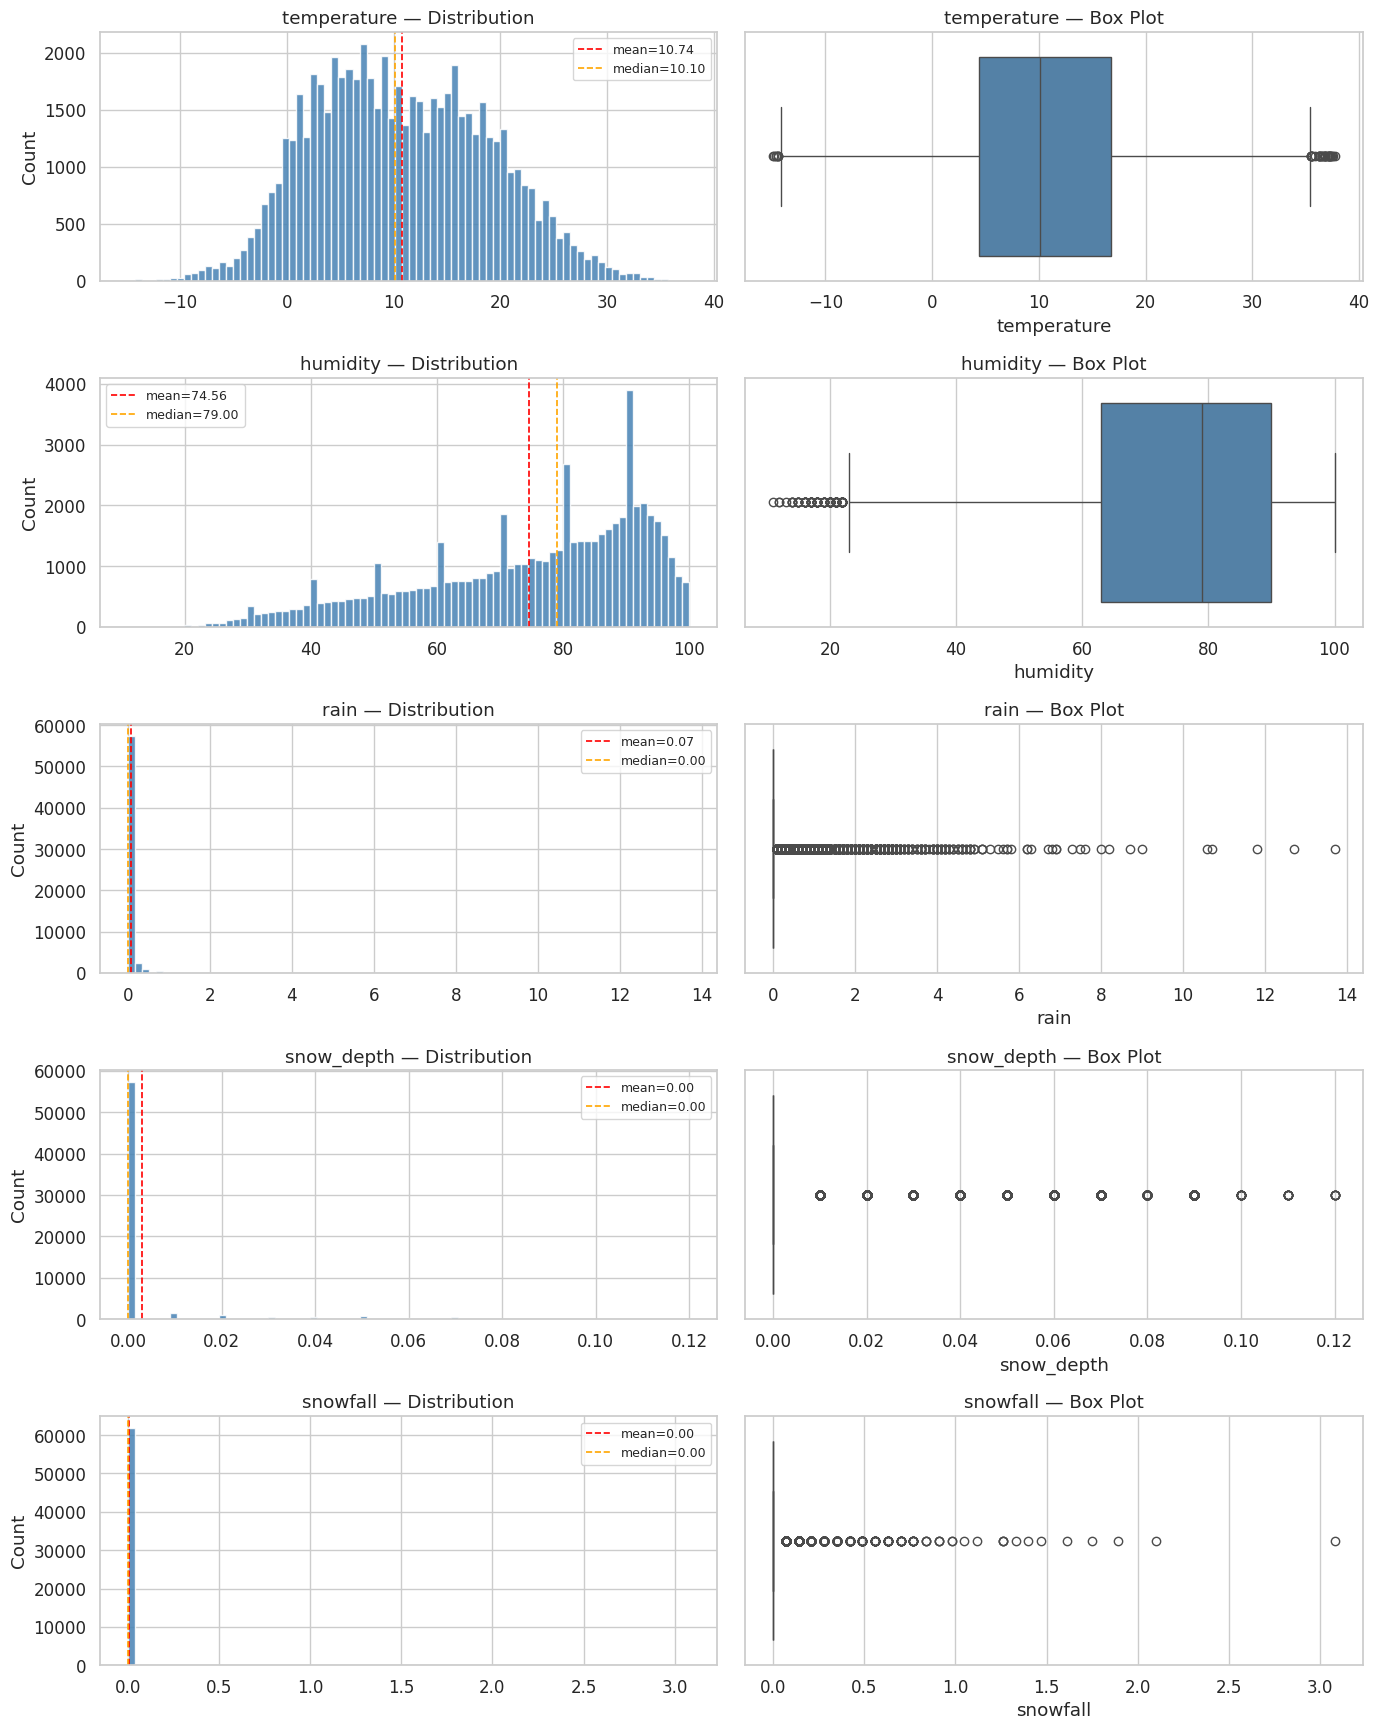

In [10]:
raw_features = ['temperature', 'humidity', 'rain', 'snow_depth', 'snowfall']

fig, axes = plt.subplots(len(raw_features), 2, figsize=(14, 3.5 * len(raw_features)))

for i, col in enumerate(raw_features):
    # Histogram
    ax_hist = axes[i, 0]
    df[col].hist(bins=80, ax=ax_hist, color='steelblue', edgecolor='white', alpha=0.85)
    ax_hist.set_title(f'{col} — Distribution')
    ax_hist.set_ylabel('Count')
    ax_hist.axvline(df[col].mean(), color='red', ls='--', lw=1.2, label=f'mean={df[col].mean():.2f}')
    ax_hist.axvline(df[col].median(), color='orange', ls='--', lw=1.2, label=f'median={df[col].median():.2f}')
    ax_hist.legend(fontsize=9)

    # Box-plot
    ax_box = axes[i, 1]
    sns.boxplot(x=df[col], ax=ax_box, color='steelblue')
    ax_box.set_title(f'{col} — Box Plot')

plt.tight_layout()
plt.show()

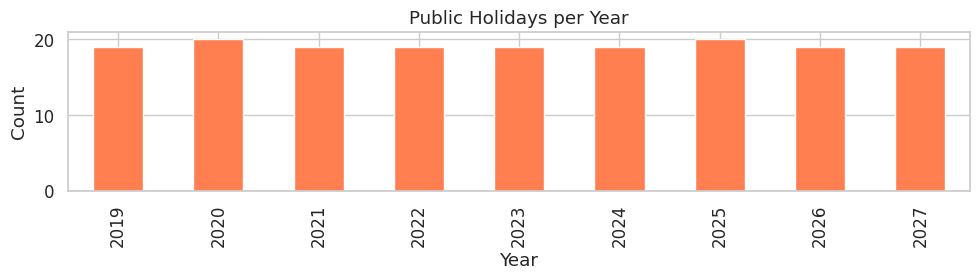

In [11]:
# ── Holiday distribution ──────────────────────────────────────────────────────
hol_per_year = holidays[holidays['is_public_holiday'] == True].groupby(holidays['date'].dt.year).size()
fig, ax = plt.subplots(figsize=(10, 3))
hol_per_year.plot.bar(ax=ax, color='coral')
ax.set_title('Public Holidays per Year')
ax.set_ylabel('Count')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()

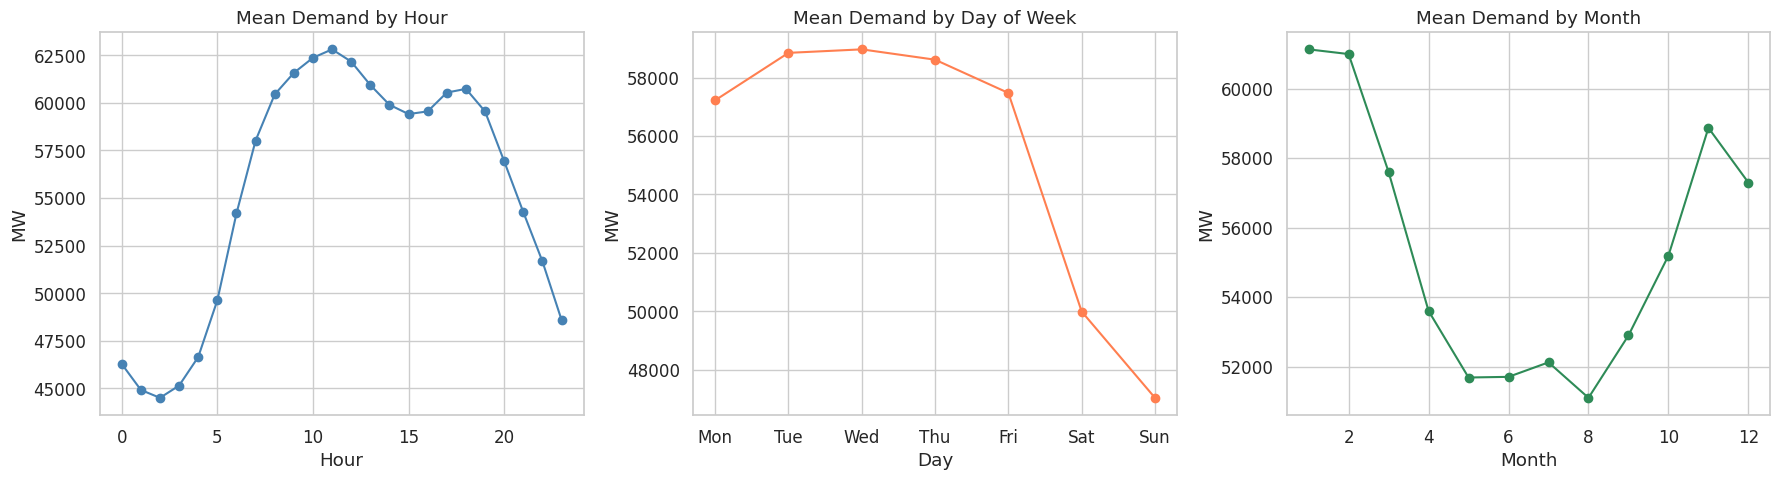

In [12]:
# ── Temporal patterns: demand by hour-of-day and day-of-week ──────────────────
df['hour'] = df['timestamp'].dt.hour
df['dow'] = df['timestamp'].dt.dayofweek
df['month'] = df['timestamp'].dt.month
df['year'] = df['timestamp'].dt.year

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# By hour
df.groupby('hour')['actual_demand'].mean().plot(ax=axes[0], marker='o', color='steelblue')
axes[0].set_title('Mean Demand by Hour')
axes[0].set_xlabel('Hour'); axes[0].set_ylabel('MW')

# By day of week
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df.groupby('dow')['actual_demand'].mean().plot(ax=axes[1], marker='o', color='coral')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(dow_labels)
axes[1].set_title('Mean Demand by Day of Week')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('MW')

# By month
df.groupby('month')['actual_demand'].mean().plot(ax=axes[2], marker='o', color='seagreen')
axes[2].set_title('Mean Demand by Month')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('MW')

plt.tight_layout()
plt.show()

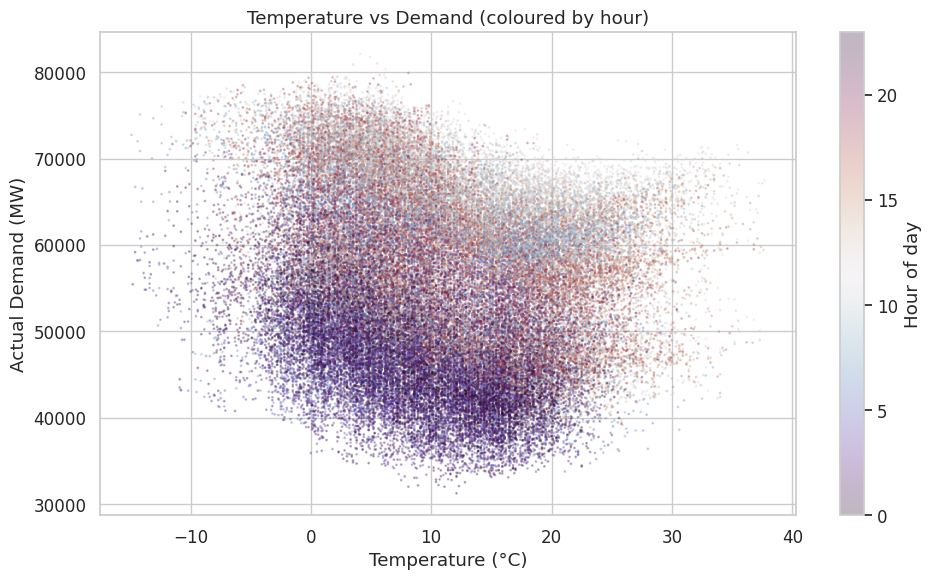

In [13]:
# ── Temperature vs demand scatter (coloured by hour) ──────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(df['temperature'], df['actual_demand'], c=df['hour'],
                     cmap='twilight_shifted', s=1, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Hour of day')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Actual Demand (MW)')
ax.set_title('Temperature vs Demand (coloured by hour)')
plt.tight_layout()
plt.show()

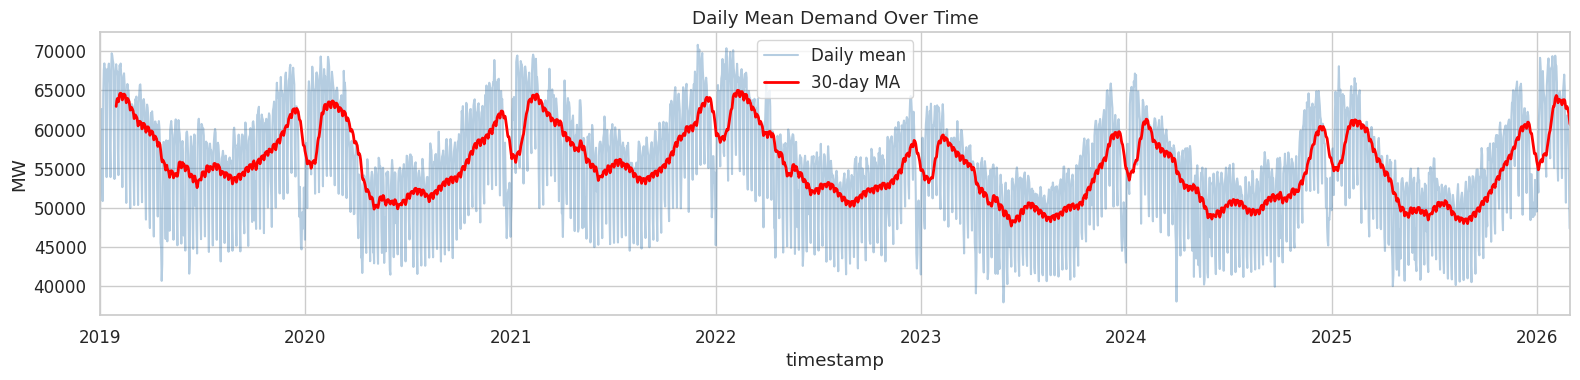

In [14]:
# ── Yearly demand trend ───────────────────────────────────────────────────────
daily_demand = df.set_index('timestamp')['actual_demand'].resample('D').mean()

fig, ax = plt.subplots(figsize=(16, 4))
daily_demand.plot(ax=ax, alpha=0.4, color='steelblue', label='Daily mean')
daily_demand.rolling(30).mean().plot(ax=ax, color='red', lw=2, label='30-day MA')
ax.set_title('Daily Mean Demand Over Time')
ax.set_ylabel('MW')
ax.legend()
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.tight_layout()
plt.show()

---
## 3 · Correlation Analysis

Pairwise Pearson correlation of **raw features only** — the columns as they exist in the database or read directly off the timestamp. No derived or engineered features. Day-ahead load forecast is excluded (leaks a third-party model's signal).

| Group | Raw features |
|---|---|
| Timestamp | `hour`, `dow`, `month` |
| Weather | `temperature`, `humidity`, `rain`, `snow_depth`, `snowfall` |
| Calendar | `is_public_holiday`, `daylight_savings_winter`, `daylight_savings_summer` |

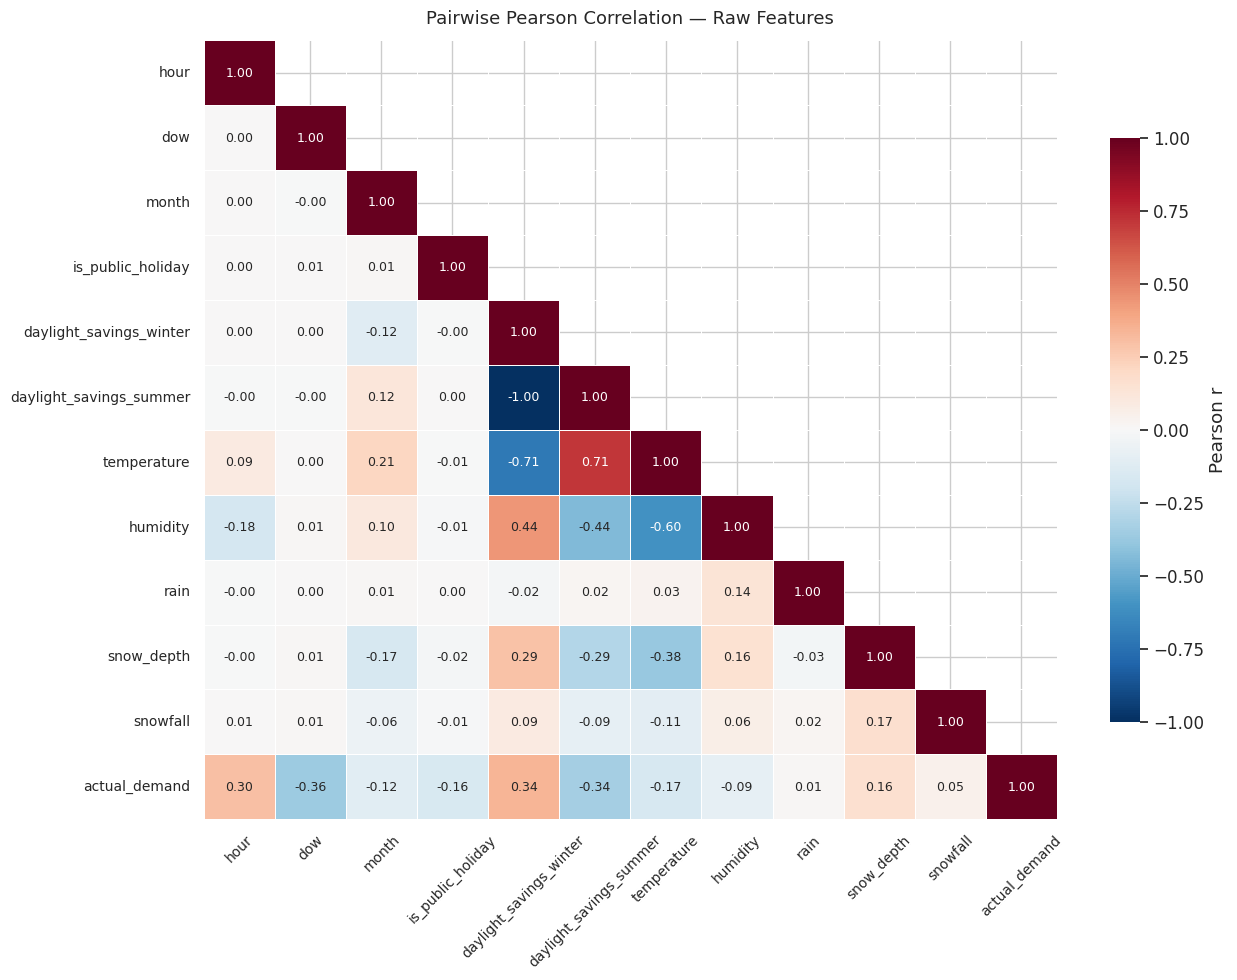

In [15]:
# ── Extract raw features from timestamp and merge ─────────────────────────────
corr_df = df.copy()

ts = corr_df['timestamp']

# Raw temporal reads — no encoding, no binarisation
corr_df['hour']  = ts.dt.hour        # 0-23
corr_df['dow']   = ts.dt.dayofweek   # 0=Mon, 6=Sun
corr_df['month'] = ts.dt.month       # 1-12

# DST indicators — computed from timestamp (same rule as DB loader)
# Not available directly in df because the load query omits them;
# computed here to keep the raw-feature set complete.
is_summer = (
    ((ts.dt.month > 3) & (ts.dt.month < 10)) |
    ((ts.dt.month == 3) & (ts.dt.day >= 25)) |
    ((ts.dt.month == 10) & (ts.dt.day < 25))
)
corr_df['daylight_savings_winter'] = (~is_summer).astype(int)
corr_df['daylight_savings_summer'] = is_summer.astype(int)

RAW_COLS = [
    # Temporal
    'hour', 'dow', 'month',
    # Calendar
    'is_public_holiday',
    # DST
    'daylight_savings_winter', 'daylight_savings_summer',
    # Weather
    'temperature', 'humidity', 'rain', 'snow_depth', 'snowfall',
    # Target
    'actual_demand',
]

corr_matrix = corr_df[RAW_COLS].corr()

# ── Full pairwise heatmap ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, ax=ax, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 9},
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'}
)
ax.set_title('Pairwise Pearson Correlation — Raw Features', fontsize=13, pad=12)
ax.tick_params(axis='x', labelsize=10, rotation=45)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.show()


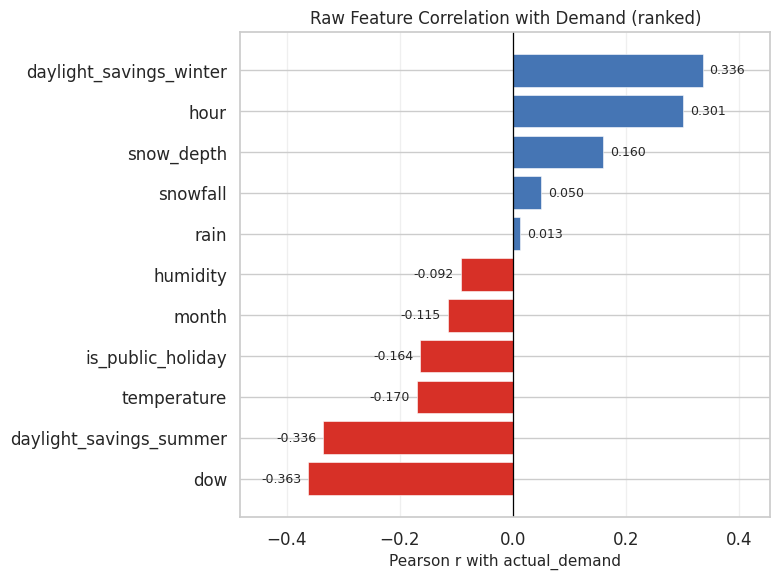


Correlation with actual_demand (sorted):
daylight_savings_winter    0.34
hour                       0.30
snow_depth                 0.16
snowfall                   0.05
rain                       0.01
humidity                  -0.09
month                     -0.12
is_public_holiday         -0.16
temperature               -0.17
daylight_savings_summer   -0.34
dow                       -0.36


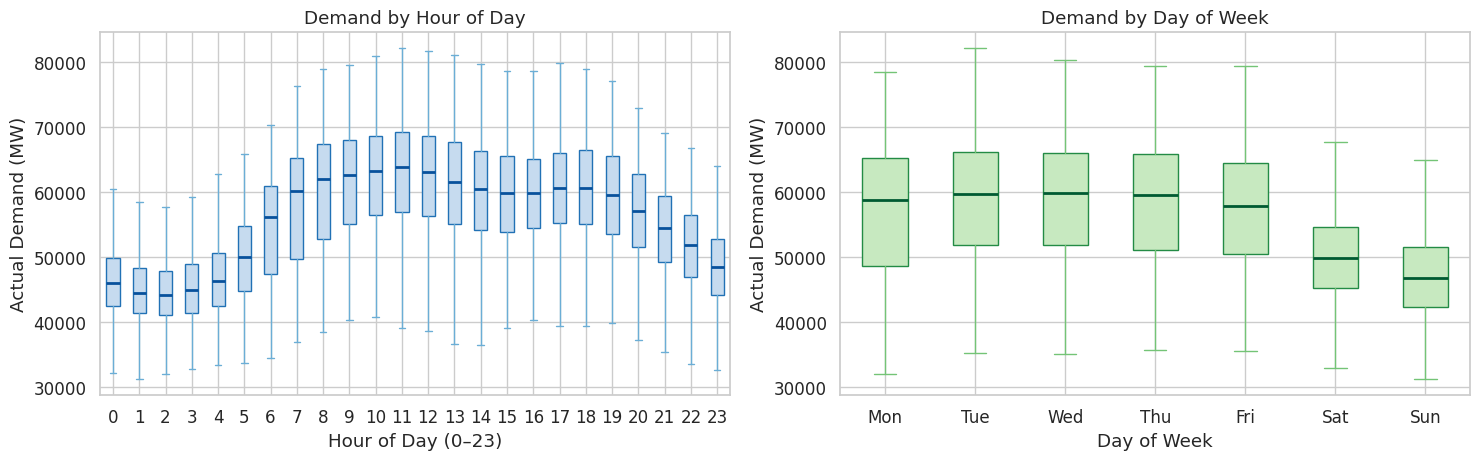

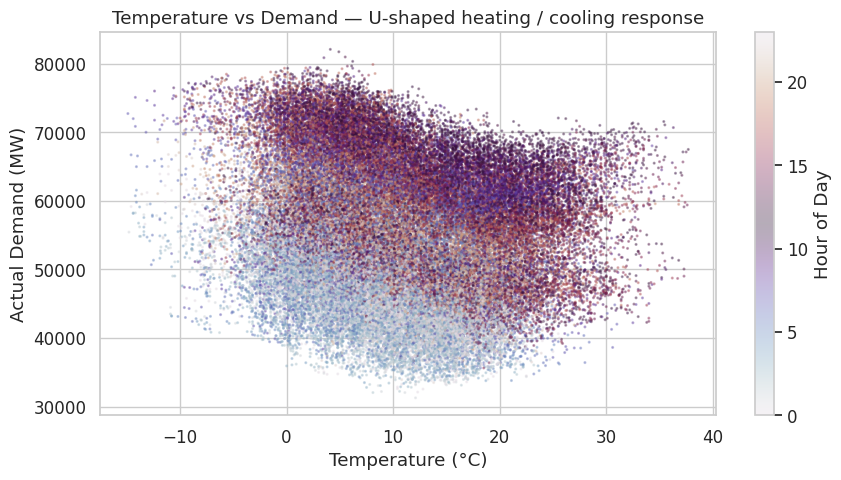

In [16]:
# ── Correlation of each raw feature with demand ───────────────────────────────
feature_cols = [c for c in RAW_COLS if c != 'actual_demand']
target_corr  = corr_matrix['actual_demand'].drop('actual_demand')[feature_cols].sort_values()

colors = ['#d73027' if v < 0 else '#4575b4' for v in target_corr]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(target_corr.index, target_corr.to_numpy(), color=colors,
               edgecolor='white', linewidth=0.4)
ax.axvline(0, color='black', lw=0.9)

for bar, val in zip(bars, target_corr.to_numpy()):
    x_pos = val + (0.012 if val >= 0 else -0.012)
    ha    = 'left' if val >= 0 else 'right'
    ax.text(x_pos, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)

ax.set_xlabel('Pearson r with actual_demand', fontsize=11)
ax.set_title('Raw Feature Correlation with Demand (ranked)', fontsize=12)
ax.set_xlim(target_corr.min() - 0.12, target_corr.max() + 0.12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nCorrelation with actual_demand (sorted):")
print(target_corr.sort_values(ascending=False).to_string())

# ── Demand distribution by hour and day-of-week (shows non-linearity) ─────────
# Note: Pearson understates the importance of hour because the relationship is
# non-monotonic (low demand at night, two peaks during day). Boxplots show this.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

corr_df.boxplot(
    column='actual_demand', by='hour', ax=axes[0],
    showfliers=False, patch_artist=True,
    boxprops=dict(facecolor='#c6dbef', color='#2171b5'),
    medianprops=dict(color='#08519c', lw=2),
    whiskerprops=dict(color='#6baed6'), capprops=dict(color='#6baed6'),
)
axes[0].set_xlabel('Hour of Day (0–23)')
axes[0].set_ylabel('Actual Demand (MW)')

corr_df.boxplot(
    column='actual_demand', by='dow', ax=axes[1],
    showfliers=False, patch_artist=True,
    boxprops=dict(facecolor='#c7e9c0', color='#238b45'),
    medianprops=dict(color='#005a32', lw=2),
    whiskerprops=dict(color='#74c476'), capprops=dict(color='#74c476'),
)
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Actual Demand (MW)')

for ax, title in zip(axes, ['Demand by Hour of Day', 'Demand by Day of Week']):
    plt.sca(ax)
    plt.title(title)
plt.suptitle('')
plt.tight_layout()
plt.show()

# ── Temperature vs Demand — U-shaped signal motivating heating_demand feature ─
fig, ax = plt.subplots(figsize=(9, 5))
sc = ax.scatter(corr_df['temperature'], corr_df['actual_demand'],
                c=corr_df['hour'], cmap='twilight', s=1.5, alpha=0.35)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Hour of Day')
ax.set_xlabel('Temperature (°C)')
ax.set_ylabel('Actual Demand (MW)')
ax.set_title('Temperature vs Demand — U-shaped heating / cooling response')
plt.tight_layout()
plt.show()

---
## 4 · PCA Analysis

Principal Component Analysis on standardised raw features.

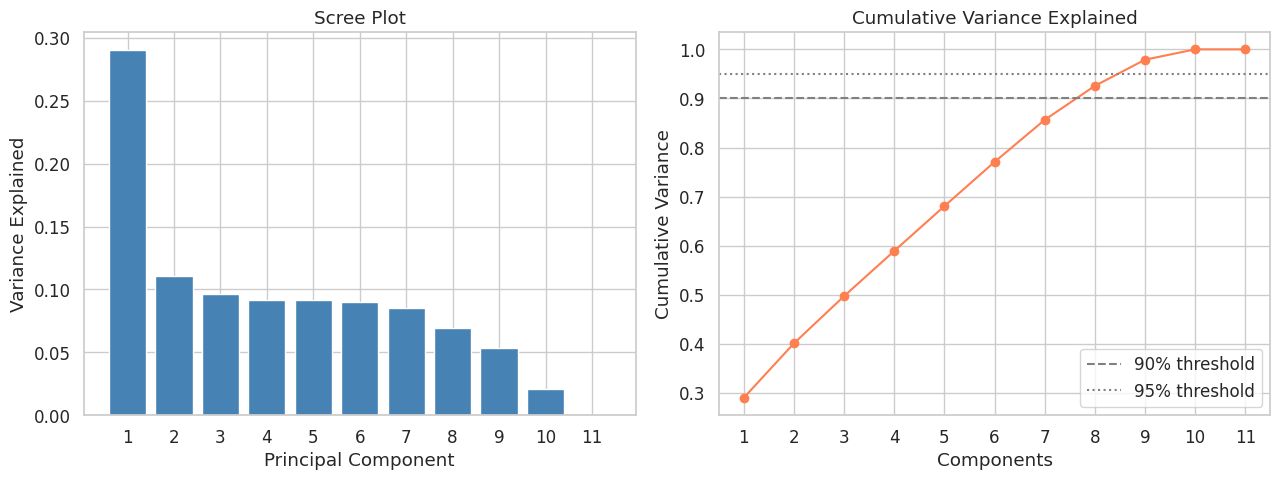

Variance explained per component:
  PC 1: 0.2902  (cumulative: 0.2902)
  PC 2: 0.1109  (cumulative: 0.4011)
  PC 3: 0.0962  (cumulative: 0.4973)
  PC 4: 0.0920  (cumulative: 0.5893)
  PC 5: 0.0913  (cumulative: 0.6806)
  PC 6: 0.0901  (cumulative: 0.7707)
  PC 7: 0.0857  (cumulative: 0.8564)
  PC 8: 0.0692  (cumulative: 0.9256)
  PC 9: 0.0533  (cumulative: 0.9789)
  PC10: 0.0211  (cumulative: 1.0000)
  PC11: 0.0000  (cumulative: 1.0000)


In [17]:
# ── PCA on raw features (same set as correlation analysis) ────────────────────
pca_features = [
    'hour', 'dow', 'month',
    'is_public_holiday', 'daylight_savings_winter', 'daylight_savings_summer',
    'temperature', 'humidity', 'rain', 'snow_depth', 'snowfall',
]

X = corr_df[pca_features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
pca.fit(X_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(range(1, len(pca_features) + 1), pca.explained_variance_ratio_,
            color='steelblue', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(range(1, len(pca_features) + 1))

axes[1].plot(range(1, len(pca_features) + 1), cumvar, 'o-', color='coral')
axes[1].axhline(0.90, ls='--', color='grey', label='90% threshold')
axes[1].axhline(0.95, ls=':',  color='grey', label='95% threshold')
axes[1].set_xlabel('Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(range(1, len(pca_features) + 1))
axes[1].legend()

plt.tight_layout()
plt.show()

print('Variance explained per component:')
for i, (var, cum) in enumerate(zip(pca.explained_variance_ratio_, cumvar)):
    print(f'  PC{i+1:>2}: {var:.4f}  (cumulative: {cum:.4f})')


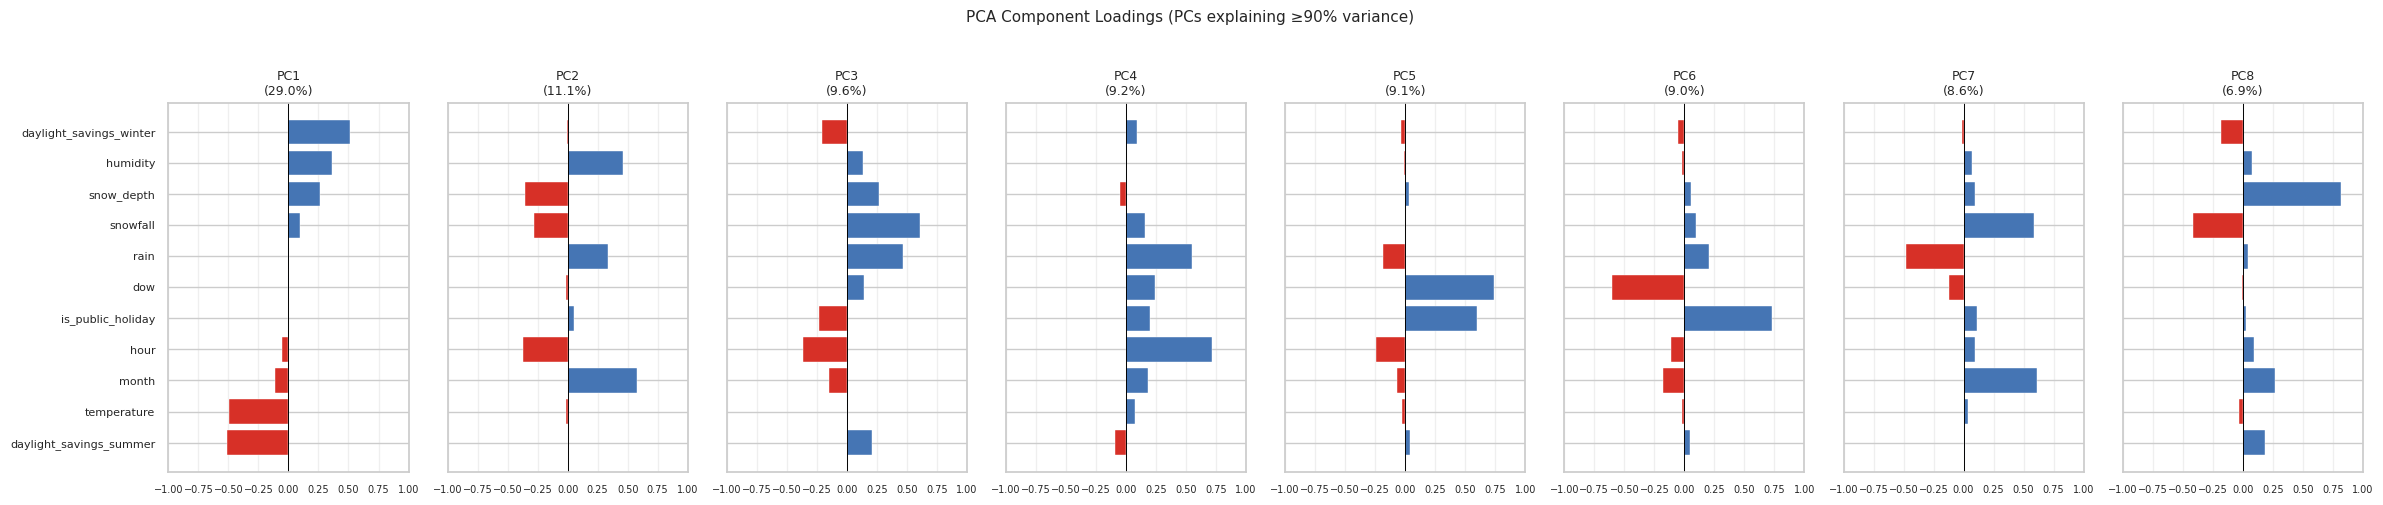


Loadings table (PCs up to 90% cumulative variance):


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8
hour,-0.05,-0.38,-0.37,0.72,-0.24,-0.11,0.10,0.09
dow,0.00,-0.01,0.14,0.24,0.74,-0.60,-0.12,-0.01
month,-0.11,0.57,-0.14,0.18,-0.07,-0.18,0.61,0.27
is_public_holiday,-0.00,0.06,-0.23,0.20,0.60,0.73,0.11,0.03
daylight_savings_winter,0.51,-0.01,-0.21,0.09,-0.04,-0.05,-0.01,-0.18
daylight_savings_summer,-0.51,0.01,0.21,-0.09,0.04,0.05,0.01,0.18
temperature,-0.50,-0.01,0.01,0.08,-0.03,-0.02,0.04,-0.03
humidity,0.36,0.46,0.14,-0.00,-0.01,-0.02,0.07,0.08
rain,0.00,0.34,0.47,0.55,-0.18,0.20,-0.48,0.04
snow_depth,0.26,-0.35,0.27,-0.05,0.03,0.06,0.09,0.82


In [18]:
# ── PCA component loadings — horizontal bar chart per component ───────────────
# Shows which raw features drive each PC; easier to read than a cluttered heatmap.
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(len(pca_features))],
    index=pca_features
)

# Only show PCs that collectively explain up to ~90% of variance
n_pcs = int(np.searchsorted(cumvar, 0.90)) + 1
loadings_trimmed = loadings.iloc[:, :n_pcs]

fig, axes = plt.subplots(1, n_pcs, figsize=(3 * n_pcs, 5), sharey=True)
if n_pcs == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    col   = loadings_trimmed.columns[i]
    vals  = loadings_trimmed[col].sort_values()
    cols  = ['#d73027' if v < 0 else '#4575b4' for v in vals]
    ax.barh(vals.index, vals.values, color=cols, edgecolor='white', linewidth=0.3)
    ax.axvline(0, color='black', lw=0.7)
    ax.set_xlim(-1, 1)
    ax.set_title(f'{col}\n({pca.explained_variance_ratio_[i]:.1%})', fontsize=9)
    ax.tick_params(axis='y', labelsize=8)
    ax.tick_params(axis='x', labelsize=7)
    ax.grid(axis='x', alpha=0.3)

fig.suptitle('PCA Component Loadings (PCs explaining ≥90% variance)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

print('\nLoadings table (PCs up to 90% cumulative variance):')
display(loadings_trimmed.round(3))


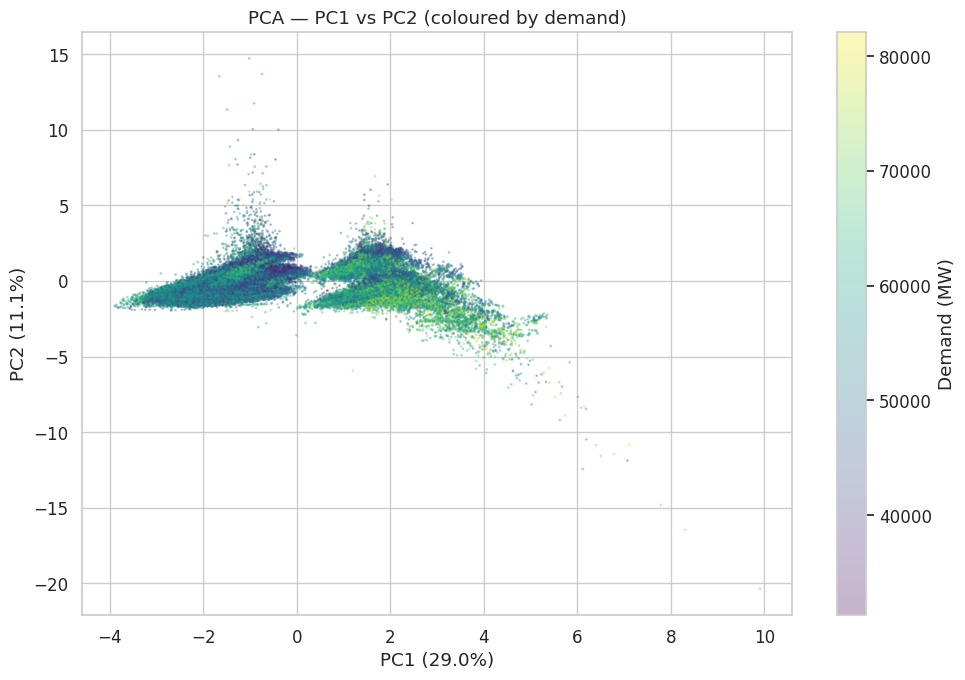

In [19]:
# ── 2D PCA scatter (PC1 vs PC2) coloured by demand ───────────────────────────
X_pca = pca.transform(X_scaled)
pca_df = pd.DataFrame(X_pca[:, :2], columns=['PC1', 'PC2'])
pca_df['demand'] = df.loc[X.index, 'actual_demand'].values

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['demand'],
                     cmap='viridis', s=1, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Demand (MW)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA — PC1 vs PC2 (coloured by demand)')
plt.tight_layout()
plt.show()

---
## 5 · Naive Baselines

Establish error floors using simple forecast strategies — any trained model should beat these.

| Baseline | Method |
|---|---|
| Persistence-24h | Use demand from 24 hours ago |
| Persistence-168h | Use demand from 1 week ago |
| Hourly-DoW Mean | Average demand for each (hour, day_of_week) |
| Seasonal Hourly-DoW | Average demand for each (hour, dow, season) |

In [20]:
def compute_metrics(actual, predicted, name=''):
    """Compute MAE, RMSE, MAPE for a forecast."""
    mask = ~(np.isnan(actual) | np.isnan(predicted))
    a, p = actual[mask], predicted[mask]
    mae = np.mean(np.abs(a - p))
    rmse = np.sqrt(np.mean((a - p) ** 2))
    mape = np.mean(np.abs((a - p) / a)) * 100
    bias = np.mean(p - a)
    return {'baseline': name, 'MAE (MW)': mae, 'RMSE (MW)': rmse, 'MAPE (%)': mape, 'Bias (MW)': bias, 'n': len(a)}

# Add temporal columns
df['season'] = df['month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Autumn', 10: 'Autumn', 11: 'Autumn',
})

# Persistence baselines
df['pred_persist_24h'] = df['actual_demand'].shift(24)
df['pred_persist_168h'] = df['actual_demand'].shift(168)

# Hourly-DoW mean baseline
hourly_dow_mean = df.groupby(['hour', 'dow'])['actual_demand'].mean()
df['pred_hourly_dow'] = df.apply(lambda r: hourly_dow_mean.get((r['hour'], r['dow']), np.nan), axis=1)

# Seasonal hourly-DoW mean baseline
seasonal_mean = df.groupby(['hour', 'dow', 'season'])['actual_demand'].mean()
df['pred_seasonal'] = df.apply(lambda r: seasonal_mean.get((r['hour'], r['dow'], r['season']), np.nan), axis=1)

# Compute metrics
baselines = []
baselines.append(compute_metrics(df['actual_demand'].values, df['pred_persist_24h'].values, 'Persistence-24h'))
baselines.append(compute_metrics(df['actual_demand'].values, df['pred_persist_168h'].values, 'Persistence-168h'))
baselines.append(compute_metrics(df['actual_demand'].values, df['pred_hourly_dow'].values, 'Hourly-DoW Mean'))
baselines.append(compute_metrics(df['actual_demand'].values, df['pred_seasonal'].values, 'Seasonal Hourly-DoW'))

baseline_df = pd.DataFrame(baselines).set_index('baseline')
display(baseline_df)

,MAE (MW),RMSE (MW),MAPE (%),Bias (MW),n
baseline,,,,,
Persistence-24h,4087.61,6171.62,7.52,-1.94,62787
Persistence-168h,2555.77,4046.18,4.73,1.10,62643
Hourly-DoW Mean,4542.08,5651.16,8.41,-0.00,62811
Seasonal Hourly-DoW,3580.98,4721.19,6.66,-0.00,62811


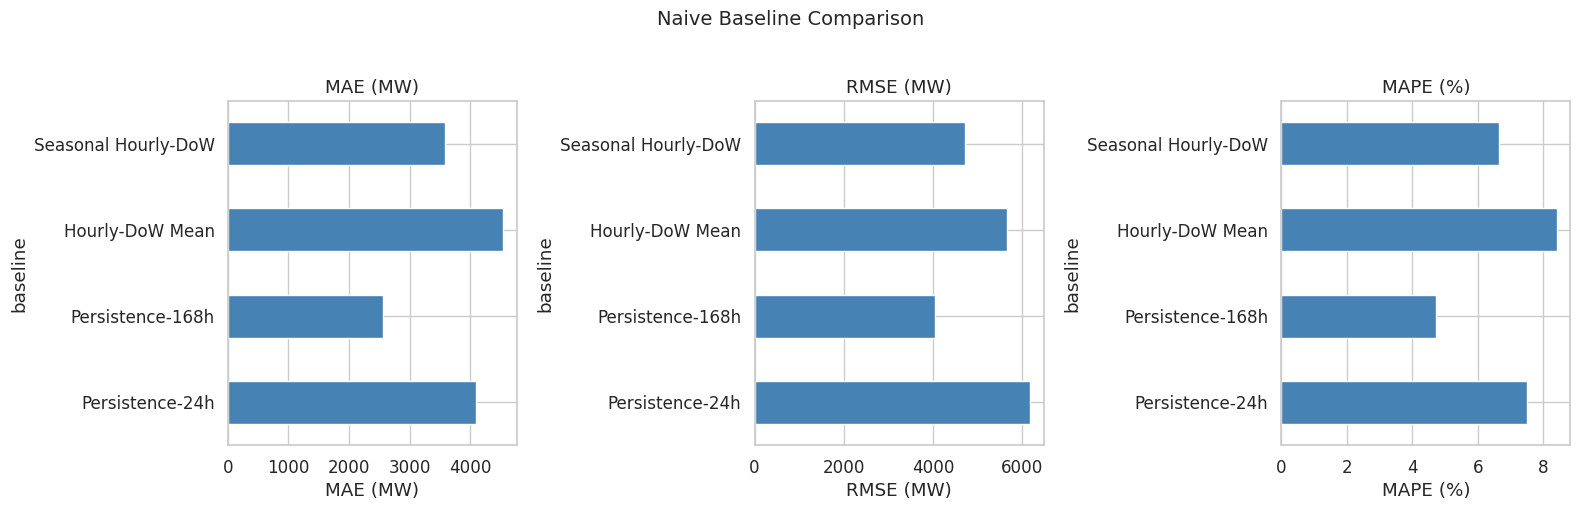

In [21]:
# ── Baseline comparison bar chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, metric in enumerate(['MAE (MW)', 'RMSE (MW)', 'MAPE (%)']):
    ax = axes[i]
    baseline_df[metric].plot.barh(ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlabel(metric)

plt.suptitle('Naive Baseline Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

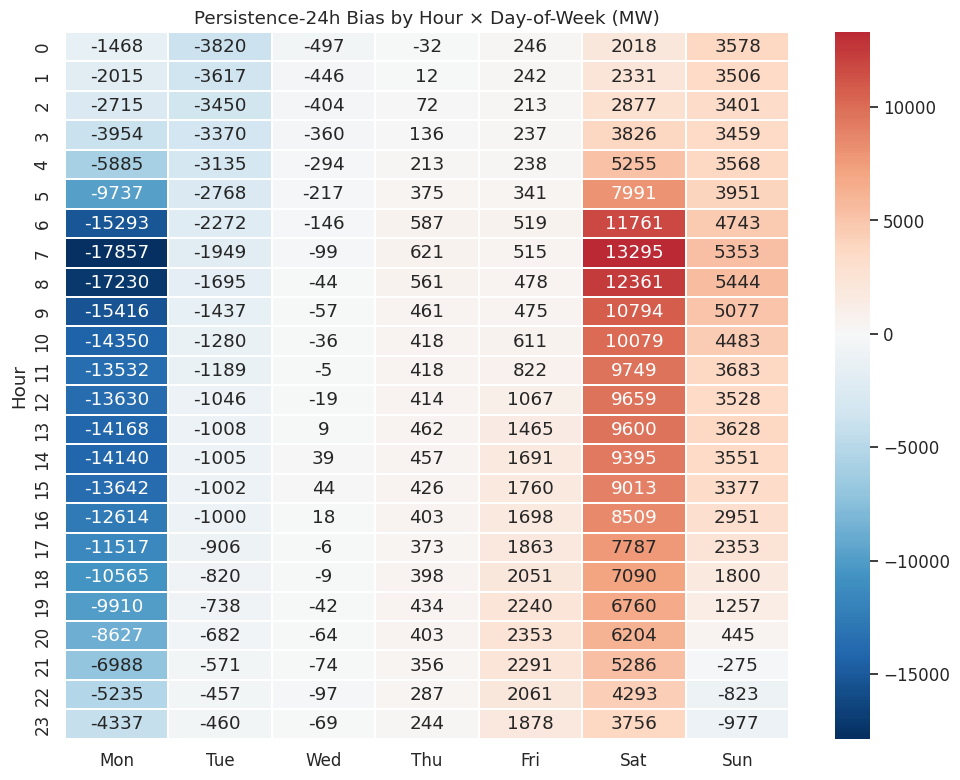


Key insight: Large positive bias = model over-predicts, negative = under-predicts.
This is the "inherent bias" pattern that any correction scheme needs to address.


In [22]:
# ── Bias analysis by hour and day-of-week (Persistence-24h) ──────────────────
df_valid = df.dropna(subset=['pred_persist_24h']).copy()
df_valid['error_24h'] = df_valid['pred_persist_24h'] - df_valid['actual_demand']

# Bias heatmap: mean error by (hour, dow)
bias_pivot = df_valid.groupby(['hour', 'dow'])['error_24h'].mean().unstack()
bias_pivot.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(bias_pivot, cmap='RdBu_r', center=0, annot=True, fmt='.0f',
            ax=ax, linewidths=0.3)
ax.set_title('Persistence-24h Bias by Hour × Day-of-Week (MW)')
ax.set_ylabel('Hour')
plt.tight_layout()
plt.show()

print('\nKey insight: Large positive bias = model over-predicts, negative = under-predicts.')
print('This is the "inherent bias" pattern that any correction scheme needs to address.')

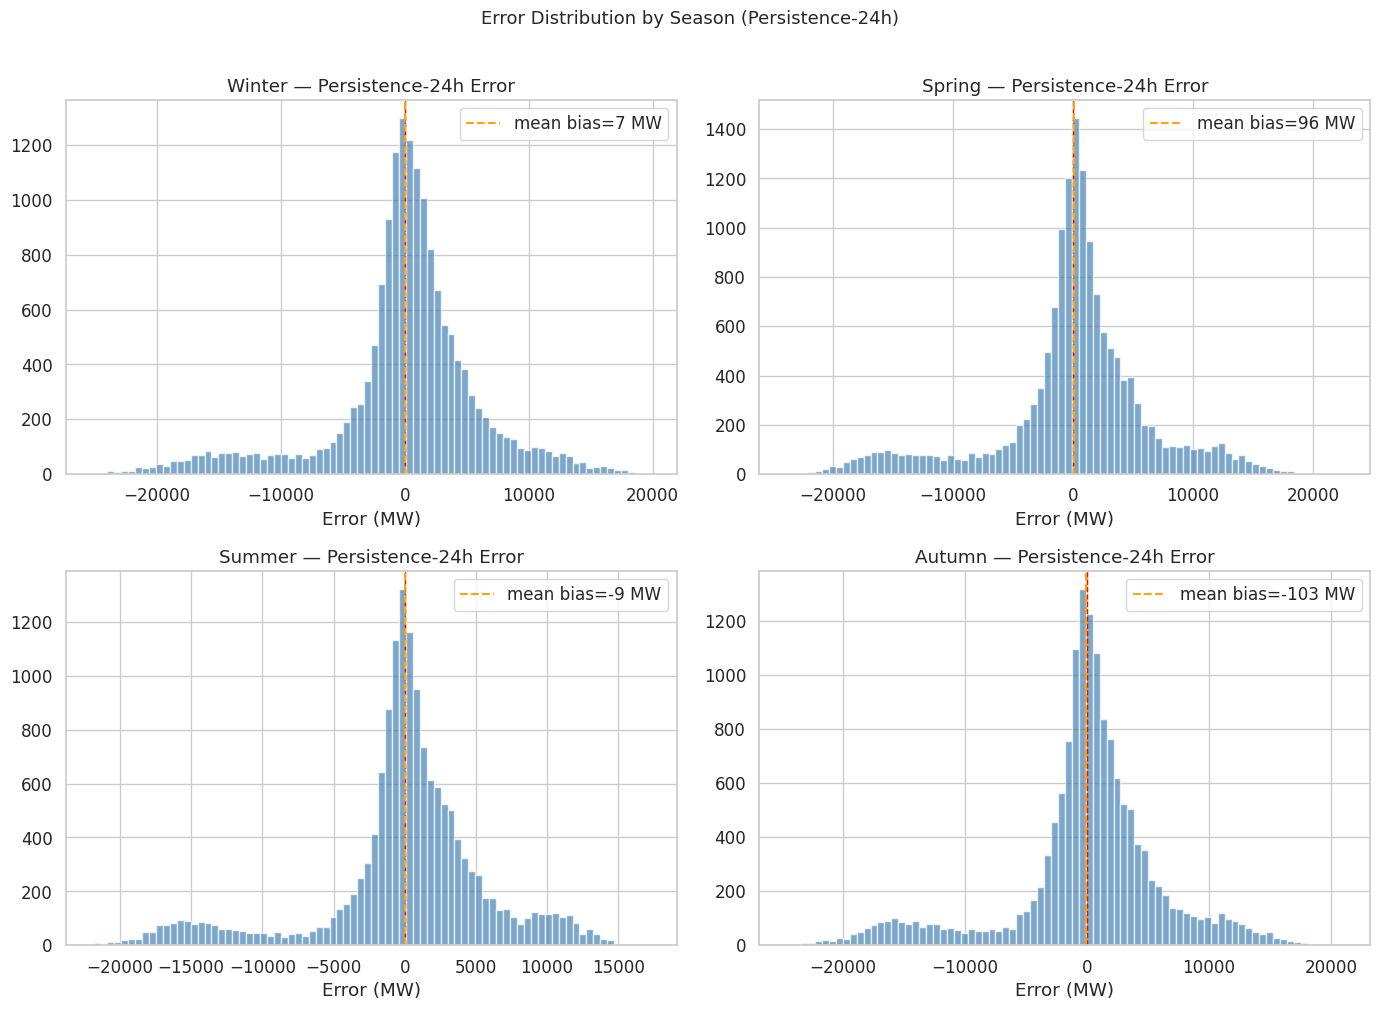

In [23]:
# ── Error distribution by season ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, season in zip(axes.flat, ['Winter', 'Spring', 'Summer', 'Autumn']):
    subset = df_valid[df_valid['season'] == season]['error_24h']
    ax.hist(subset, bins=80, color='steelblue', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='red', ls='--', lw=1)
    ax.axvline(subset.mean(), color='orange', ls='--', lw=1.5,
               label=f'mean bias={subset.mean():.0f} MW')
    ax.set_title(f'{season} — Persistence-24h Error')
    ax.set_xlabel('Error (MW)')
    ax.legend()

plt.suptitle('Error Distribution by Season (Persistence-24h)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

,MAE (MW),RMSE (MW),MAPE (%),Bias (MW),n
baseline,,,,,
2019,4519.76,6874.08,8.05,-8.33,8735
2020,4084.99,6141.18,7.44,-0.95,8783
2021,4126.45,6251.61,7.22,-3.78,8759
2022,4036.38,6107.76,7.38,16.48,8759
2023,3950.67,5968.07,7.63,1.55,8759
2024,3978.47,5953.61,7.60,-17.44,8783
2025,3924.62,5865.16,7.45,-2.13,8759
2026,4047.94,6091.45,6.65,4.17,1450


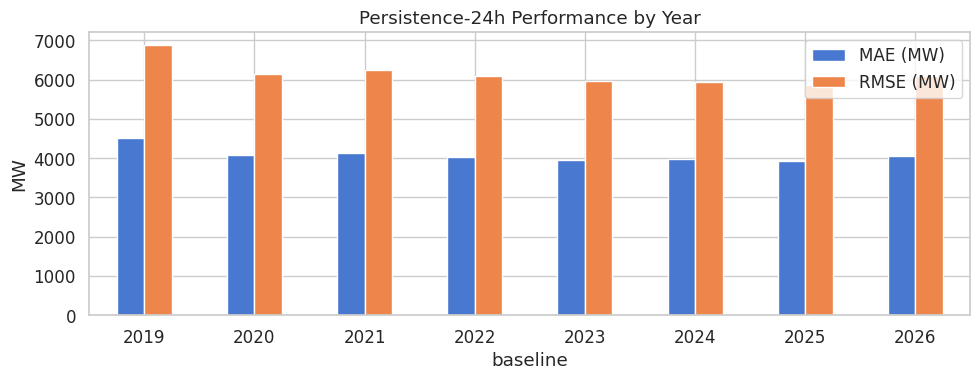

In [24]:
# ── Year-over-year baseline performance ──────────────────────────────────────
yearly_metrics = []
for year in sorted(df_valid['year'].unique()):
    mask = df_valid['year'] == year
    subset = df_valid[mask]
    m = compute_metrics(subset['actual_demand'].values, subset['pred_persist_24h'].values, str(year))
    yearly_metrics.append(m)

yearly_df = pd.DataFrame(yearly_metrics).set_index('baseline')
display(yearly_df)

fig, ax = plt.subplots(figsize=(10, 4))
yearly_df[['MAE (MW)', 'RMSE (MW)']].plot.bar(ax=ax)
ax.set_title('Persistence-24h Performance by Year')
ax.set_ylabel('MW')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

---
## Summary

**Next steps:**
1. Review data quality flags above and fix any gaps/issues in the pipeline
2. The PCA loadings show which raw features carry the most variance
3. The naive baselines set the error floor — the TFT model must beat these
4. The bias heatmap reveals systematic hour × dow patterns that any model (or post-hoc correction) needs to capture
5. Proceed to **Notebook 02** for model evaluation and feature importance